In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

archivo = "Trabajo_Almacenamiento_Eléctrico_python.xlsx"

xls = pd.ExcelFile(archivo)

print(xls.sheet_names)

['Power instaled', 'Potencia instalada', 'Generation 2023', 'Generation 2030 Renovable']


Leemos los datos del excel

In [11]:
df_2023 = pd.read_excel(
    archivo,
    sheet_name="Generation 2023",
    header=3
)

df_2023 = df_2023.iloc[:105120].copy()
df_2023.head(5)

,MES,Fecha,Hour,Nuclear,Fuel,Coal,CCG,Co-generation and waste,Hydo,Wind,PV,Solar Thermal,Renewable thermal,Total,Renovable,NO Renovable,%Renovable
0,Enero,2023-01-01,00:00:00,6465.0,0,251.0,2296.0,929.0,552.0,7054.0,20.0,0.0,253.0,17820.0,7626.0,10194.0,0.427946
1,Enero,2023-01-01,00:05:00,6468.0,0,276.0,2278.0,936.0,229.0,6702.0,20.0,0.0,236.0,17145.0,6951.0,10194.0,0.405424
2,Enero,2023-01-01,00:10:00,6470.0,0,289.0,2341.0,935.0,204.0,6295.0,20.0,0.0,236.0,16790.0,6519.0,10271.0,0.388267
3,Enero,2023-01-01,00:15:00,6467.0,0,292.0,2286.0,945.0,168.0,6230.0,20.0,0.0,236.0,16644.0,6418.0,10226.0,0.385604
4,Enero,2023-01-01,00:20:00,6465.0,0,301.0,2227.0,936.0,145.0,6129.0,20.0,0.0,236.0,16459.0,6294.0,10165.0,0.382405


In [12]:
df_2030r = pd.read_excel(
    archivo,
    sheet_name="Generation 2030 Renovable",
    header=3
)

df_2030r = df_2030r.iloc[:105120].copy()
df_2030r.head(5)

,MES,Fecha,Hour,Nuclear,Fuel,Coal,CCG,Co-generation and waste,Hydo,Wind,PV,Solar Thermal,Renewable thermal,Total,Renovable,NO Renovable,%Renovable
0,Enero,2023-01-01,00:00:00,2762.296464,0.0,0.0,2290.031877,632.754061,393.525608,14374.924268,73.630874,0.0,407.629998,20934.79315,15249.710748,5685.082402,0.728439
1,Enero,2023-01-01,00:05:00,2763.578272,0.0,0.0,2272.078665,637.521853,163.256095,13657.604542,73.630874,0.0,380.239840,19947.910141,14274.731352,5673.178790,0.715600
2,Enero,2023-01-01,00:10:00,2764.432811,0.0,0.0,2334.914906,636.840739,145.433377,12828.203610,73.630874,0.0,380.239840,19163.696157,13427.507701,5736.188456,0.700674
3,Enero,2023-01-01,00:15:00,2763.151003,0.0,0.0,2280.057870,643.651870,119.768663,12695.744002,73.630874,0.0,380.239840,18956.244123,13269.383379,5686.860743,0.700001
4,Enero,2023-01-01,00:20:00,2762.296464,0.0,0.0,2221.211232,637.521853,103.371763,12489.922149,73.630874,0.0,380.239840,18668.194175,13047.164626,5621.029549,0.698898


In [30]:
Aumento_consumo= 0.16
df_2023["Consumo_2030"] = df_2023["Total"] * (1+Aumento_consumo)
df_2023[["Total", "Consumo_2030"]].head()

,Total,Consumo_2030
0,17820.0,20671.20
1,17145.0,19888.20
2,16790.0,19476.40
3,16644.0,19307.04
4,16459.0,19092.44


In [77]:
esc_r = pd.DataFrame({
    "Fecha": df_2030r["Fecha"],
    "Hour": df_2030r["Hour"],
    "Consumo": df_2023["Consumo_2030"],
    "Renovable": df_2030r["Renovable"]
})

# positivo = falta energía
# negativo = excedente
esc_r["Balance"] = esc_r["Consumo"] - esc_r["Renovable"]

esc_r.head(5)

,Fecha,Hour,Consumo,Renovable,Balance
0,2023-01-01,00:00:00,20671.20,15249.710748,5421.489252
1,2023-01-01,00:05:00,19888.20,14274.731352,5613.468648
2,2023-01-01,00:10:00,19476.40,13427.507701,6048.892299
3,2023-01-01,00:15:00,19307.04,13269.383379,6037.656621
4,2023-01-01,00:20:00,19092.44,13047.164626,6045.275374


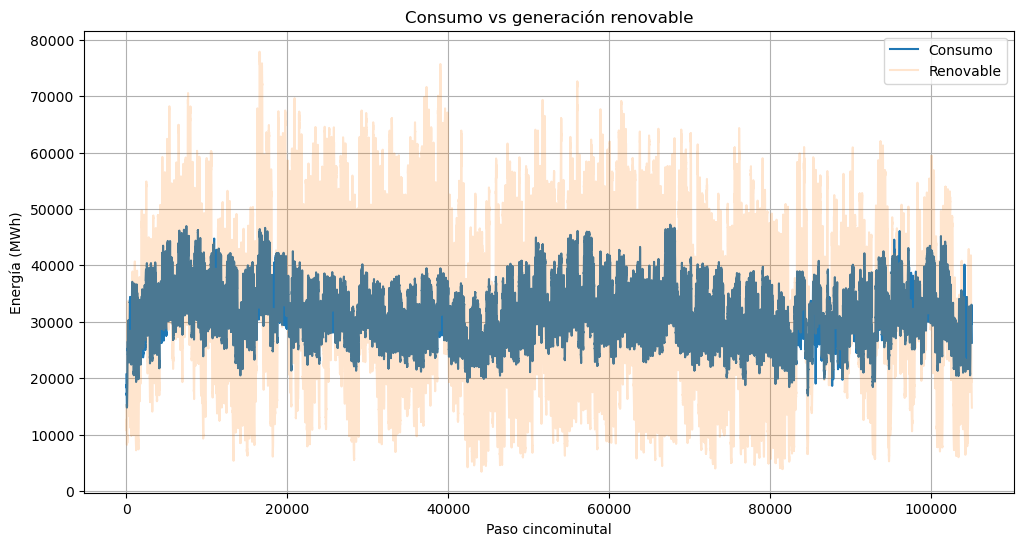

In [38]:
plt.figure(figsize=(12,6))

plt.plot(esc_r["Consumo"], label="Consumo", alpha=1)
plt.plot(esc_r["Renovable"], label="Renovable", alpha=0.2)

plt.xlabel("Paso cincominutal")
plt.ylabel("Potencia (MW)")

plt.title("Consumo vs generación renovable")

plt.legend()
plt.grid(True)

plt.show()

In [21]:
def optimizar_almacenamiento_minimo(df, col_gen, col_cons="Consumo", frac_min=0.1):

    out = df.copy()

    delta = out[col_gen] - out[col_cons]

    C = delta.cumsum()

    Cmin = C.min()
    Cmax = C.max()

    R = Cmax - Cmin

    S_max = R / (1 - frac_min)

    S_min = frac_min * S_max

    S0 = S_min - Cmin

    almacenamiento = S0 + C

    out["Delta"] = delta
    out["Acumulado"] = C
    out["Almacenamiento_optimo"] = almacenamiento

    return out, S_max, S_min, S0

In [39]:
esc_r_opt, Smax, Smin, S0 = optimizar_almacenamiento_minimo(
    esc_r,
    col_gen="Renovable",
    col_cons="Consumo",
    frac_min=0.1
)

print("Capacidad total almacenamiento Smax (MWh):", Smax)
print("Capacidad mínima Smin (MWh):", Smin)
print("Capacidad útil (MWh):", Smax - Smin)

esc_r_opt.head(5)

Capacidad total almacenamiento Smax (MWh): 151621221.91083828
Capacidad mínima Smin (MWh): 15162122.191083828
Capacidad útil (MWh): 136459099.71975446


,Fecha,Hour,Consumo,Renovable,Balance,Delta,Acumulado,Almacenamiento_optimo
0,2023-01-01,00:00:00,20671.20,15249.710748,5421.489252,-5421.489252,-5421.489252,1.249776e+08
1,2023-01-01,00:05:00,19888.20,14274.731352,5613.468648,-5613.468648,-11034.957900,1.249720e+08
2,2023-01-01,00:10:00,19476.40,13427.507701,6048.892299,-6048.892299,-17083.850199,1.249659e+08
3,2023-01-01,00:15:00,19307.04,13269.383379,6037.656621,-6037.656621,-23121.506819,1.249599e+08
4,2023-01-01,00:20:00,19092.44,13047.164626,6045.275374,-6045.275374,-29166.782193,1.249538e+08


In [23]:
delta = esc_r_opt["Delta"]

P_carga = delta.clip(lower=0).max() * 12
P_descarga = (-delta.clip(upper=0)).max() * 12

print("Potencia carga (MW):", P_carga)
print("Potencia descarga (MW):", P_descarga)

Potencia carga (MW): 437362.4817208253
Potencia descarga (MW): 332076.70420761907


In [27]:
esc_r_opt["Almacenamiento_util"] = esc_r_opt["Almacenamiento_optimo"] - Smin
esc_r_opt.head(5)

,Fecha,Hour,Consumo,Renovable,Balance,Delta,Acumulado,Almacenamiento_optimo,Almacenamiento_util
0,2023-01-01,00:00:00,20671.20,15249.710748,5421.489252,-5421.489252,-5421.489252,1.249776e+08,1.098155e+08
1,2023-01-01,00:05:00,19888.20,14274.731352,5613.468648,-5613.468648,-11034.957900,1.249720e+08,1.098099e+08
2,2023-01-01,00:10:00,19476.40,13427.507701,6048.892299,-6048.892299,-17083.850199,1.249659e+08,1.098038e+08
3,2023-01-01,00:15:00,19307.04,13269.383379,6037.656621,-6037.656621,-23121.506819,1.249599e+08,1.097978e+08
4,2023-01-01,00:20:00,19092.44,13047.164626,6045.275374,-6045.275374,-29166.782193,1.249538e+08,1.097917e+08


## plt.figure(figsize=(12,6))

plt.plot(esc_r_opt["Almacenamiento_optimo"], label="Almacenamiento total")
plt.plot(esc_r_opt["Almacenamiento_util"], label="Almacenamiento útil")

plt.axhline(Smin, linestyle="--", label="Smin")
plt.axhline(Smax, linestyle="--", label="Smax")

plt.xlabel("Paso cincominutal")
plt.ylabel("Potencia (MW)")
plt.title("Comparación entre almacenamiento total y útil")

plt.legend()
plt.grid(True)
plt.show()

## Renovable + CCG

In [40]:
esc_r_ccg = pd.DataFrame({
    "Fecha": df_2030r["Fecha"],
    "Hour": df_2030r["Hour"],
    "Consumo": df_2023["Consumo_2030"],
    "Renovable": df_2030r["Renovable"]
})

# CCG cubre solo lo que no cubre la renovable
esc_r_ccg["CCG_necesario"] = np.maximum(esc_r_ccg["Consumo"] - esc_r_ccg["Renovable"], 0)

# Exceso renovable perdido si no hay almacenamiento
esc_r_ccg["Exceso_R_sin_almacenamiento"] = np.maximum(esc_r_ccg["Renovable"] - esc_r_ccg["Consumo"], 0)

# Generación total del sistema en este caso
esc_r_ccg["Generacion_total"] = esc_r_ccg["Renovable"] + esc_r_ccg["CCG_necesario"]

esc_r_ccg.head(5)

,Fecha,Hour,Consumo,Renovable,CCG_necesario,Exceso_R_sin_almacenamiento,Generacion_total
0,2023-01-01,00:00:00,20671.20,15249.710748,5421.489252,0.0,20671.20
1,2023-01-01,00:05:00,19888.20,14274.731352,5613.468648,0.0,19888.20
2,2023-01-01,00:10:00,19476.40,13427.507701,6048.892299,0.0,19476.40
3,2023-01-01,00:15:00,19307.04,13269.383379,6037.656621,0.0,19307.04
4,2023-01-01,00:20:00,19092.44,13047.164626,6045.275374,0.0,19092.44


In [80]:
ER_perdida_total = esc_r_ccg["Exceso_R_sin_almacenamiento"].sum()/12
energia_total_ccg = esc_r_ccg["CCG_necesario"].sum()/12

print("ER perdida sin almacenamiento (MWh):", ER_perdida_total)
print("Energía total producida por CCG (MWh):", energia_total_ccg)

ER perdida sin almacenamiento (MWh): 47369205.33863738
Energía total producida por CCG (MWh): 56520945.832177944


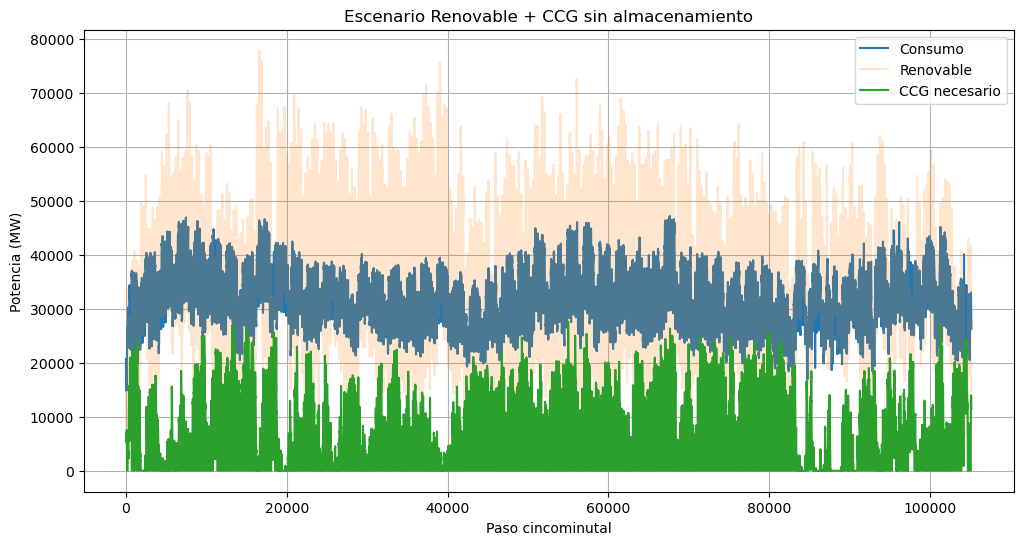

In [81]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg["Consumo"], label="Consumo")
plt.plot(esc_r_ccg["Renovable"], label="Renovable", alpha=0.2)
plt.plot(esc_r_ccg["CCG_necesario"], label="CCG necesario")

plt.xlabel("Paso cincominutal")
plt.ylabel("Potencia (MW)")
plt.title("Escenario Renovable + CCG sin almacenamiento")

plt.legend()
plt.grid(True)
plt.show()

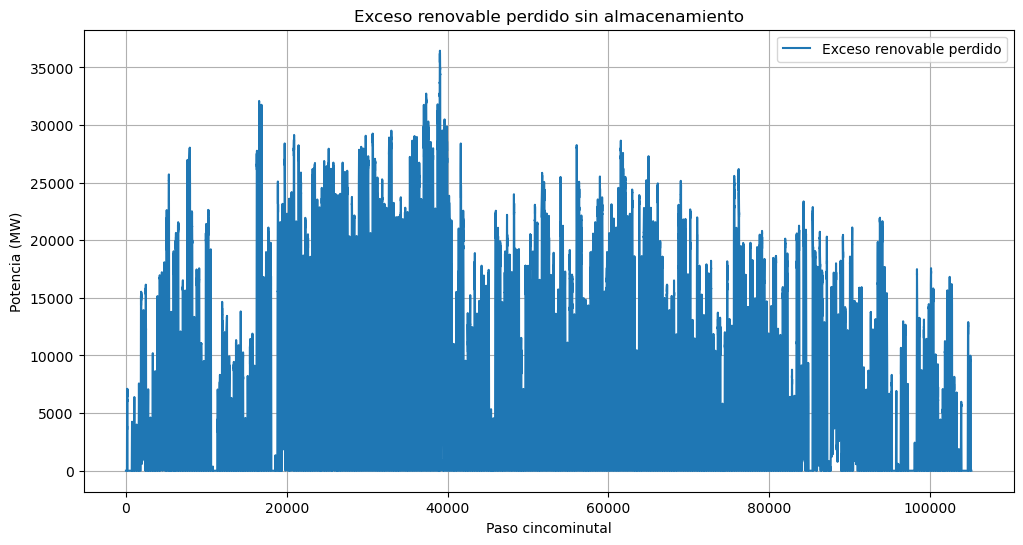

In [82]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg["Exceso_R_sin_almacenamiento"], label="Exceso renovable perdido")

plt.xlabel("Paso cincominutal")
plt.ylabel("Potencia (MW)")
plt.title("Exceso renovable perdido sin almacenamiento")

plt.legend()
plt.grid(True)
plt.show()

### Si se quiere evitar el curtailment de las energías renovables, obtener el almacenamiento necesario y obtener las horas equivalentes de funcionamiento de las centrales de CCG

In [48]:
def almacenamiento_minimo_sin_curtailment(df, col_gen="Renovable", col_cons="Consumo"):
    """
    Dimensiona el almacenamiento mínimo para evitar curtailment renovable
    cuando existe CCG que cubre el déficit restante.

    - Carga cuando gen > cons
    - Descarga cuando gen < cons (si hay energía almacenada)
    - Si no hay almacenamiento suficiente, entra CCG

    Devuelve:
    - df con columnas de flujo, almacenamiento, CCG
    - Smax mínimo necesario
    """

    out = df.copy()

    delta = out[col_gen] - out[col_cons]  # excedente positivo, déficit negativo
    n = len(delta)

    flujo = np.zeros(n)
    almacen = np.zeros(n)
    ccg = np.zeros(n)

    s = 0
    s_max = 0

    for i in range(n):
        d = delta.iloc[i]

        if d > 0:
            # cargar almacenamiento
            s += d
            flujo[i] = d
        else:
            # descargar almacenamiento
            descarga = min(-d, s)
            s -= descarga
            flujo[i] = -descarga

            # lo que falte lo cubre el CCG
            ccg[i] = (-d) - descarga

        almacen[i] = s
        s_max = max(s_max, s)

    out["Delta"] = delta
    out["Flujo_almacenamiento"] = flujo
    out["Almacenamiento"] = almacen
    out["CCG"] = ccg

    return out, s_max

In [49]:
esc_r_ccg_opt, Smax_ccg = almacenamiento_minimo_sin_curtailment(
    esc_r_ccg,
    col_gen="Renovable",
    col_cons="Consumo"
)

print("Almacenamiento mínimo necesario (MW):", Smax_ccg)

Almacenamiento mínimo necesario (MWh): 102458120.70293687


In [50]:
exceso = np.maximum(esc_r_ccg["Renovable"] - esc_r_ccg["Consumo"], 0)

print("Excedente renovable total (MW):", exceso.sum())
print("Almacenamiento máximo utilizado (MW):", esc_r_ccg_opt["Almacenamiento"].max())
exceso = np.maximum(esc_r_ccg["Renovable"] - esc_r_ccg["Consumo"], 0)

print("Excedente renovable total (MW):", exceso.sum())
print("Almacenamiento máximo utilizado (MW):", esc_r_ccg_opt["Almacenamiento"].max())

Excedente renovable total (MWh): 568430464.0636486
Almacenamiento máximo utilizado (MWh): 102458120.70293687
Excedente renovable total (MWh): 568430464.0636486
Almacenamiento máximo utilizado (MWh): 102458120.70293687


In [60]:
df_power = pd.read_excel(
    archivo,
    sheet_name="Power instaled",
    header=1
)

df_power.head()

,USAR ESTOS para cada mes de 2023,Unnamed: 1,datos en MW,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Energía,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
1,Nuclear,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29
2,Fuel,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95
3,Carbón,3223.165,3223.165,3223.165,3223.165,3223.165,3223.165,3223.165,3223.165,3223.165,3223.165,3223.165,3223.165
4,Ciclos,24561.845,24561.845,24561.845,24561.845,24561.845,24561.845,24561.845,24561.845,24561.845,24561.845,24561.845,24561.845


In [83]:
# Si la columna CCG está en MWh por intervalo de 5 min:
energia_ccg_MWh = esc_r_ccg_opt["CCG"].sum() * (5/60)  # o /12

print("Energía anual CCG (MWh):", energia_ccg_MWh)
potencia_ccg =  24498   # Pniec

horas_equivalentes = energia_ccg / potencia_ccg

print("Horas equivalentes de funcionamiento CCG:", horas_equivalentes)

Energía anual CCG (MWh): 9151740.493540488
Horas equivalentes de funcionamiento CCG: 4482.851086720789


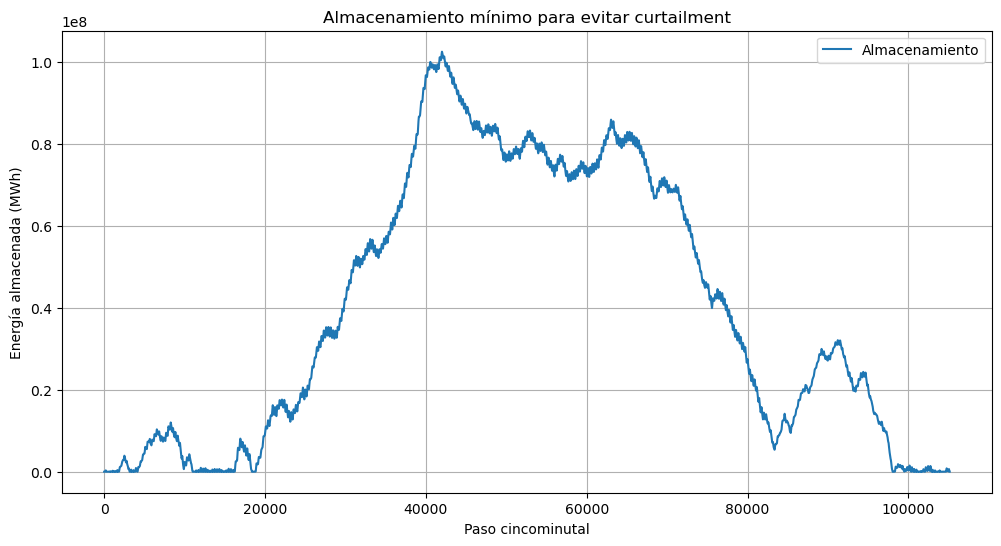

In [84]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg_opt["Almacenamiento"], label="Almacenamiento")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía almacenada (MWh)")
plt.title("Almacenamiento mínimo para evitar curtailment")

plt.legend()
plt.grid(True)

### Si se dispone de un máximo de 50 GWh:
• ¿Se satisface el 100% de la demanda?
• ¿Cuánta ER se pierde?
• Obtener las horas equivalentes de funcionamiento de las centrales de CCG

In [69]:
def simulacion_con_limite(df, col_gen="Renovable", col_cons="Consumo", Smax=50000):

    out = df.copy()

    delta = out[col_gen] - out[col_cons]

    n = len(delta)

    almacen = np.zeros(n)
    ccg = np.zeros(n)
    vertido = np.zeros(n)

    s = 0

    for i in range(n):

        d = delta.iloc[i]

        if d > 0:

            carga = min(d, Smax - s)
            s += carga

            vertido[i] = d - carga

        else:

            descarga = min(-d, s)
            s -= descarga

            ccg[i] = (-d) - descarga

        almacen[i] = s

    out["Almacenamiento"] = almacen
    out["CCG"] = ccg
    out["Vertido_ER"] = vertido

    return out

In [70]:
esc_r_ccg_50 = simulacion_con_limite(
    esc_r_ccg,
    col_gen="Renovable",
    col_cons="Consumo",
    Smax=50000
)

esc_r_ccg_50.head()

,Fecha,Hour,Consumo,Renovable,CCG_necesario,Exceso_R_sin_almacenamiento,Generacion_total,Almacenamiento,CCG,Vertido_ER
0,2023-01-01,00:00:00,20671.20,15249.710748,5421.489252,0.0,20671.20,0.0,5421.489252,0.0
1,2023-01-01,00:05:00,19888.20,14274.731352,5613.468648,0.0,19888.20,0.0,5613.468648,0.0
2,2023-01-01,00:10:00,19476.40,13427.507701,6048.892299,0.0,19476.40,0.0,6048.892299,0.0
3,2023-01-01,00:15:00,19307.04,13269.383379,6037.656621,0.0,19307.04,0.0,6037.656621,0.0
4,2023-01-01,00:20:00,19092.44,13047.164626,6045.275374,0.0,19092.44,0.0,6045.275374,0.0


In [71]:
demanda_no_cubierta = np.maximum(
    esc_r_ccg_50["Consumo"] -
    (esc_r_ccg_50["Renovable"] + esc_r_ccg_50["CCG"]),
    0
).sum()

print("Demanda no cubierta (MWh):", demanda_no_cubierta)

Demanda no cubierta (MWh): 17237717.622045904


In [72]:
ER_perdida = esc_r_ccg_50["Vertido_ER"].sum()

print("Energía renovable perdida (MWh):", ER_perdida)

Energía renovable perdida (MWh): 551192746.4416027


In [73]:
ER_perdida = esc_r_ccg_50["Vertido_ER"].sum()

print("Energía renovable perdida (MWh):", ER_perdida)
potencia_ccg = 24498  # MW

horas_equivalentes = energia_ccg / potencia_ccg

print("Horas equivalentes de funcionamiento CCG:", horas_equivalentes)

Energía renovable perdida (MWh): 551192746.4416027
Horas equivalentes de funcionamiento CCG: 4482.851086720789


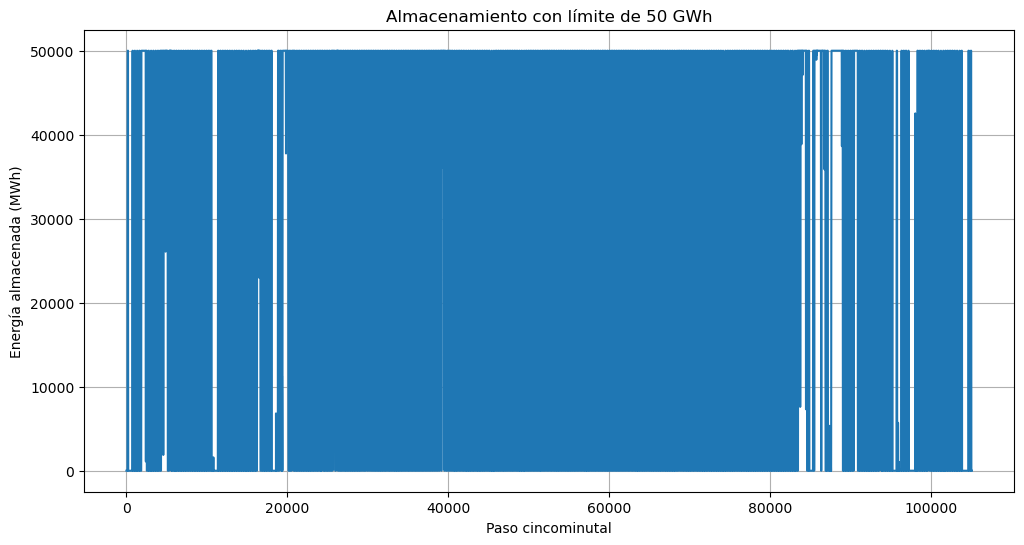

In [74]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg_50["Almacenamiento"])

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía almacenada (MWh)")
plt.title("Almacenamiento con límite de 50 GWh")

plt.grid(True)
plt.show()

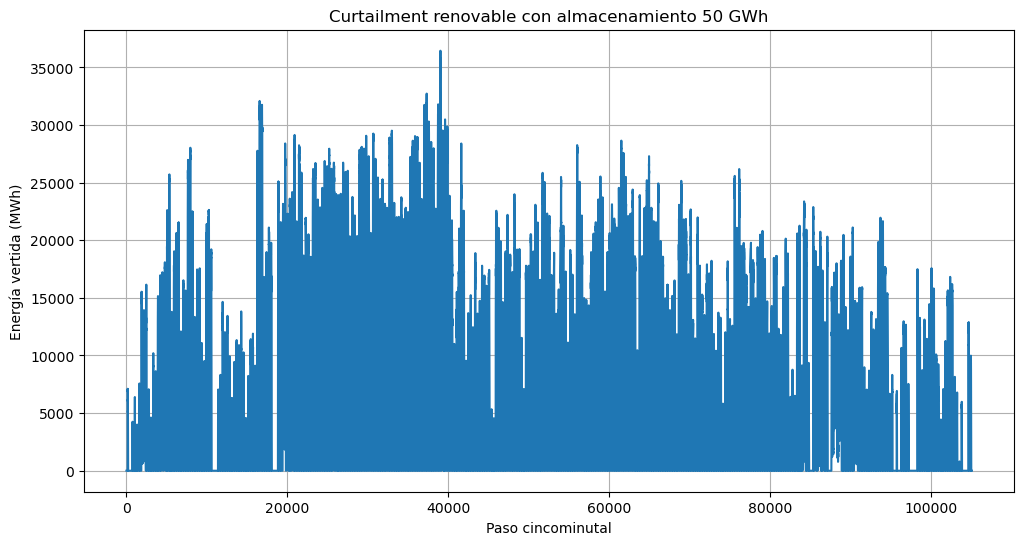

In [75]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg_50["Vertido_ER"])

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía vertida (MWh)")
plt.title("Curtailment renovable con almacenamiento 50 GWh")

plt.grid(True)
plt.show()

## R+CCG+N

In [85]:
esc_r_n_ccg = pd.DataFrame({
    "Fecha": df_2030r["Fecha"],
    "Hour": df_2030r["Hour"],
    "Consumo": df_2023["Consumo_2030"],
    "Renovable": df_2030r["Renovable"],
    "Nuclear": df_2030r["Nuclear"]
})

# Generación base sin CCG
esc_r_n_ccg["Gen_R_N"] = esc_r_n_ccg["Renovable"] + esc_r_n_ccg["Nuclear"]

esc_r_n_ccg.head()

,Fecha,Hour,Consumo,Renovable,Nuclear,Gen_R_N
0,2023-01-01,00:00:00,20671.20,15249.710748,2762.296464,18012.007212
1,2023-01-01,00:05:00,19888.20,14274.731352,2763.578272,17038.309624
2,2023-01-01,00:10:00,19476.40,13427.507701,2764.432811,16191.940512
3,2023-01-01,00:15:00,19307.04,13269.383379,2763.151003,16032.534382
4,2023-01-01,00:20:00,19092.44,13047.164626,2762.296464,15809.461090


### Sin almacenamiento

In [86]:
esc_r_n_ccg["CCG"] = np.maximum(
    esc_r_n_ccg["Consumo"] - esc_r_n_ccg["Gen_R_N"], 0)

esc_r_n_ccg["Vertido_ER"] = np.maximum(
    esc_r_n_ccg["Gen_R_N"] - esc_r_n_ccg["Consumo"], 0)

In [87]:
ER_perdida = esc_r_n_ccg["Vertido_ER"].sum() / 12

print("ER perdida sin almacenamiento (MWh):", ER_perdida)

ER perdida sin almacenamiento (MWh): 57387980.972496726


In [ ]:
### Evitar Curtailment

In [88]:
def almacenamiento_optimo_RN(df):

    out = df.copy()

    delta = out["Gen_R_N"] - out["Consumo"]

    n = len(delta)

    s = 0
    s_max = 0

    almacen = np.zeros(n)
    ccg = np.zeros(n)

    for i in range(n):

        d = delta.iloc[i]

        if d > 0:
            s += d
        else:
            descarga = min(-d, s)
            s -= descarga
            ccg[i] = (-d) - descarga

        almacen[i] = s
        s_max = max(s_max, s)

    out["Almacenamiento"] = almacen
    out["CCG"] = ccg

    return out, s_max

In [89]:
energia_ccg = esc_r_n_ccg["CCG"].sum() / 12

horas_equivalentes = energia_ccg / potencia_ccg

print("Horas equivalentes CCG:", horas_equivalentes)

Horas equivalentes CCG: 1767.4855762273364


In [100]:
def optimizar_almacenamiento_curtailment(df, col_gen="Gen_R_N", col_cons="Consumo", frac_min=0.1):
    """
    Minimiza el almacenamiento necesario para evitar curtailment,
    imponiendo S_min = frac_min * S_max.

    Devuelve:
    - dataframe con delta, acumulado y almacenamiento óptimo
    - Smax, Smin, S0
    """

    out = df.copy()

    # Excedente positivo, déficit negativo
    delta = out[col_gen] - out[col_cons]

    # Curva acumulada
    C = delta.cumsum()

    Cmin = C.min()
    Cmax = C.max()
    R = Cmax - Cmin

    # Como la capacidad útil es (1-frac_min)*Smax
    Smax = R / (1 - frac_min)
    Smin = frac_min * Smax

    # Nivel inicial mínimo factible
    S0 = Smin - Cmin

    # Trayectoria óptima
    S = S0 + C

    # CCG residual: solo cuando el almacenamiento tocaría el mínimo
    ccg = np.zeros(len(out))
    for i in range(1, len(out)):
        if delta.iloc[i] < 0:
            descarga_posible = S.iloc[i-1] - Smin
            deficit = -delta.iloc[i]
            ccg[i] = max(0, deficit - descarga_posible)

    out["Delta"] = delta
    out["Acumulado"] = C
    out["Almacenamiento_optimo"] = S
    out["Almacenamiento_util"] = S - Smin
    out["CCG"] = ccg

    return out, Smax, Smin, S0

In [101]:
esc_r_n_ccg_opt, Smax_RN, Smin_RN, S0_RN = optimizar_almacenamiento_curtailment(
    esc_r_n_ccg,
    col_gen="Gen_R_N",
    col_cons="Consumo",
    frac_min=0.1
)

print("Smax (MWh):", Smax_RN / 12)
print("Smin (MWh):", Smin_RN / 12)
print("S0 (MWh):", S0_RN / 12)

Smax (MWh): 20303236.64735874
Smin (MWh): 2030323.6647358742
S0 (MWh): 3826290.079082483


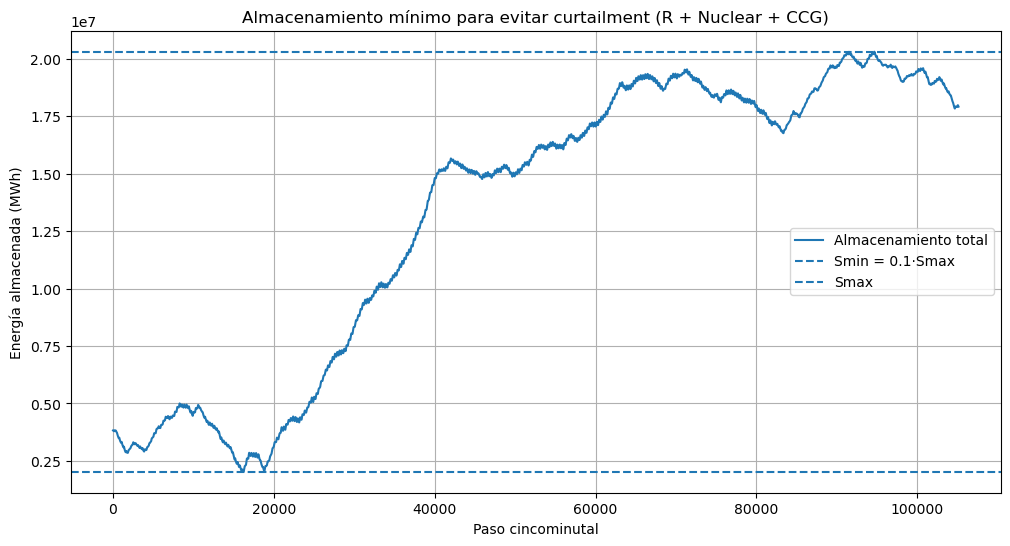

In [102]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_n_ccg_opt["Almacenamiento_optimo"] / 12, label="Almacenamiento total")

plt.axhline(Smin_RN / 12, linestyle="--", label="Smin = 0.1·Smax")
plt.axhline(Smax_RN / 12, linestyle="--", label="Smax")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía almacenada (MWh)")
plt.title("Almacenamiento mínimo para evitar curtailment (R + Nuclear + CCG)")

plt.legend()
plt.grid(True)
plt.show()

In [103]:
energia_ccg = esc_r_n_ccg_opt["CCG"].sum() / 12

horas_equivalentes = energia_ccg / potencia_ccg

print("Horas equivalentes CCG:", horas_equivalentes)

Horas equivalentes CCG: 0.0


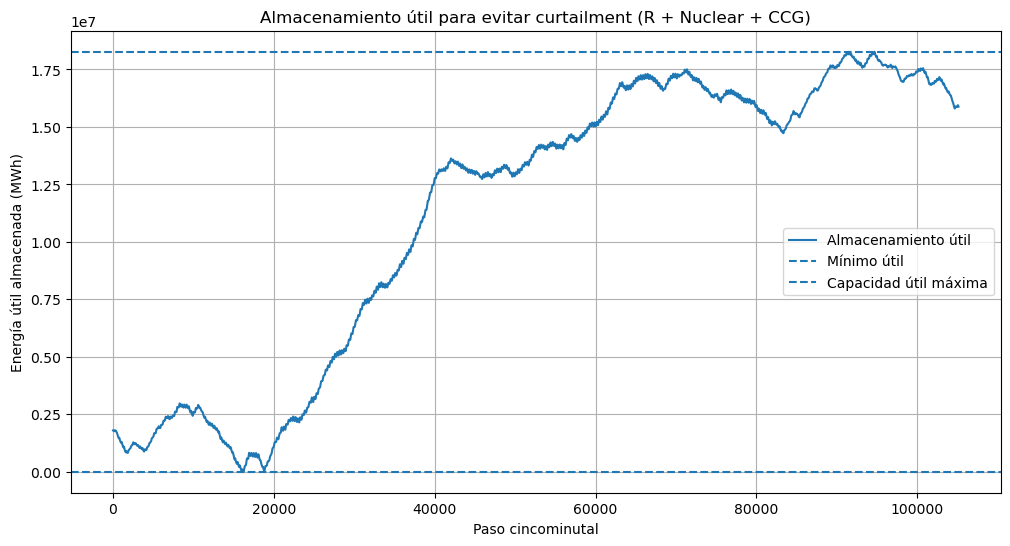

In [104]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_n_ccg_opt["Almacenamiento_util"] / 12, label="Almacenamiento útil")

plt.axhline(0, linestyle="--", label="Mínimo útil")
plt.axhline((Smax_RN - Smin_RN) / 12, linestyle="--", label="Capacidad útil máxima")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía útil almacenada (MWh)")
plt.title("Almacenamiento útil para evitar curtailment (R + Nuclear + CCG)")

plt.legend()
plt.grid(True)
plt.show()

In [93]:
### 50 GWh

In [112]:
Smax_lim = 50000 * 12
Smin_lim = 0.1 * Smax_lim

In [113]:
def almacenamiento_limite_RN_con_min(df, Smax, frac_min=0.1):

    out = df.copy()

    delta = out["Gen_R_N"] - out["Consumo"]

    n = len(delta)

    Smin = frac_min * Smax
    S0 = Smin   # puedes arrancar en mínimo técnico

    s = S0

    almacen = np.zeros(n)
    almacen_util = np.zeros(n)
    ccg = np.zeros(n)
    vertido = np.zeros(n)

    for i in range(n):

        d = delta.iloc[i]

        if d > 0:
            # sobra energía, se carga hasta Smax
            carga = min(d, Smax - s)
            s += carga
            vertido[i] = d - carga

        else:
            # falta energía, se descarga hasta Smin
            descarga = min(-d, s - Smin)
            s -= descarga
            ccg[i] = (-d) - descarga

        almacen[i] = s
        almacen_util[i] = s - Smin

    out["Delta"] = delta
    out["Almacenamiento"] = almacen
    out["Almacenamiento_util"] = almacen_util
    out["CCG"] = ccg
    out["Vertido_ER"] = vertido

    return out, Smax, Smin, S0

In [114]:
Smax_lim = 50000 * 12

esc_r_n_ccg_50, Smax_lim, Smin_lim, S0_lim = almacenamiento_limite_RN_con_min(
    esc_r_n_ccg,
    Smax=Smax_lim,
    frac_min=0.1
)

In [115]:
demanda_no_cubierta = np.maximum(
    esc_r_n_ccg_50["Consumo"] -
    (esc_r_n_ccg_50["Gen_R_N"] + esc_r_n_ccg_50["CCG"]),
    0
).sum()

print("Demanda no cubierta:", demanda_no_cubierta)

Demanda no cubierta: 155318716.54789138


In [116]:
ER_perdida = esc_r_n_ccg_50["Vertido_ER"].sum() / 12

print("ER perdida (MWh):", ER_perdida)

ER perdida (MWh): 44444754.59350578


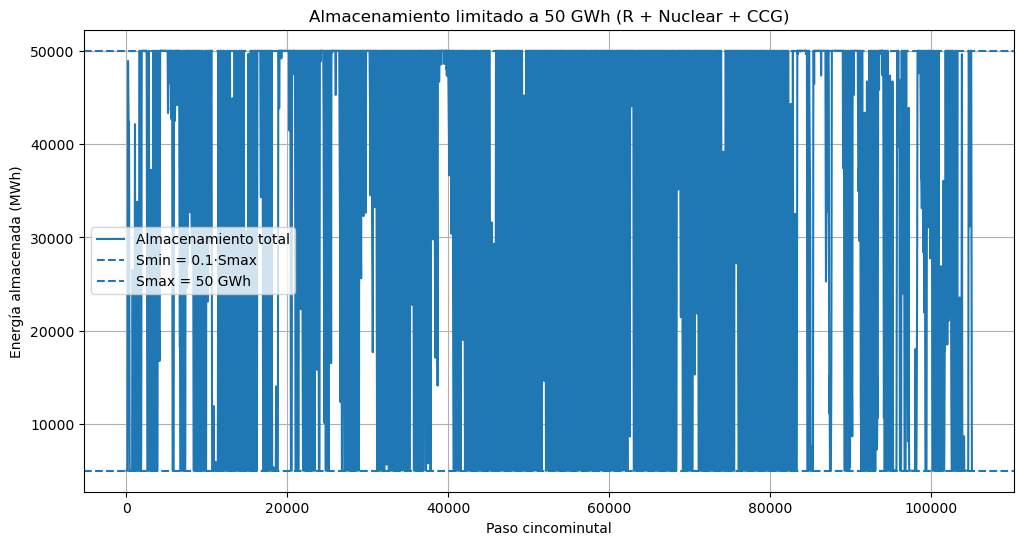

In [117]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_n_ccg_50["Almacenamiento"] / 12, label="Almacenamiento total")

plt.axhline(Smin_lim / 12, linestyle="--", label="Smin = 0.1·Smax")
plt.axhline(Smax_lim / 12, linestyle="--", label="Smax = 50 GWh")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía almacenada (MWh)")
plt.title("Almacenamiento limitado a 50 GWh (R + Nuclear + CCG)")

plt.legend()
plt.grid(True)
plt.show()

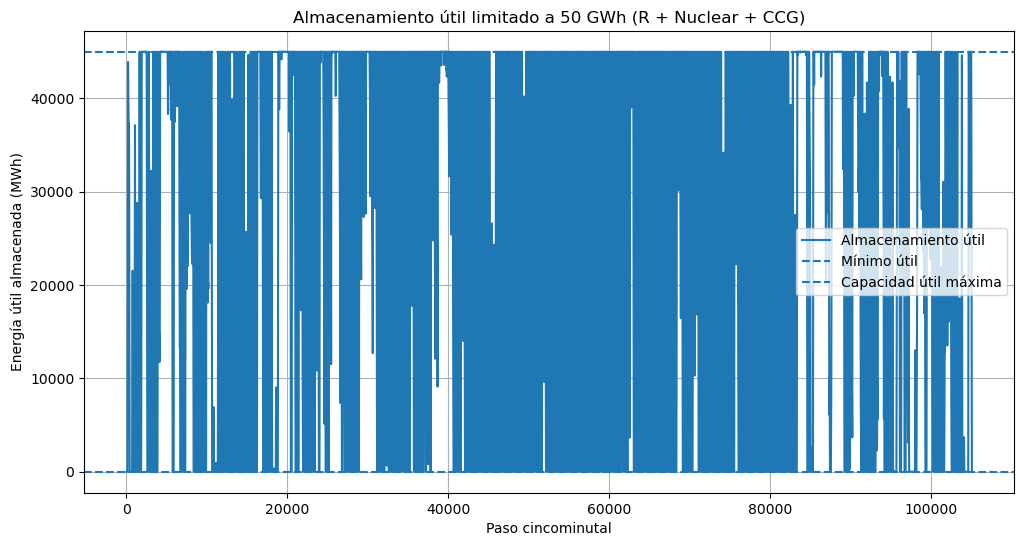

In [118]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_n_ccg_50["Almacenamiento_util"] / 12, label="Almacenamiento útil")

plt.axhline(0, linestyle="--", label="Mínimo útil")
plt.axhline((Smax_lim - Smin_lim) / 12, linestyle="--", label="Capacidad útil máxima")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía útil almacenada (MWh)")
plt.title("Almacenamiento útil limitado a 50 GWh (R + Nuclear + CCG)")

plt.legend()
plt.grid(True)
plt.show()